In [ ]:
# Notebook safety defaults for static analysis / first-run clarity
# These are harmless fallbacks and are overwritten by real config cells.
if 'deployment_name' not in globals():
    deployment_name = ""

if 'question_data' not in globals():
    question_data = {"diagram_description": ""}

if 'client' not in globals():
    class _MissingClient:
        class chat:
            class completions:
                @staticmethod
                def create(*args, **kwargs):
                    raise RuntimeError("Azure OpenAI client is not initialized. Run the setup cells first.")

    client = _MissingClient()

In [1]:
# Install pyodbc if not already installed
%pip install pyodbc

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
# Cell: Generate diagram code using Azure OpenAI and render diagram
import json
from io import BytesIO
import base64
import matplotlib.pyplot as plt
from IPython.display import HTML, display

print("Generating diagram code with Azure OpenAI...")
diagram_response = client.chat.completions.create(
    model=deployment_name,
    messages=[{
        "role": "system",
        "content": "You are an expert in creating matplotlib code for mathematical diagrams. You must create diagrams that EXACTLY match the problem description with NO errors or inconsistencies."
    }, {
        "role": "user",
        "content": f'''Create Python matplotlib code to draw this diagram: {question_data['diagram_description']}\n\nCRITICAL REQUIREMENTS - READ CAREFULLY:\n\nGEOMETRIC ACCURACY (MOST IMPORTANT):\n1. If drawing a triangle, the three points MUST NOT be collinear (on the same line)\n2. If the question mentions coordinates, use EXACT coordinate values from the problem\n3. Calculate point positions mathematically to ensure geometric relationships are correct\n4. For ratios like AD:DB = 1:3, calculate exact positions: if A=(0,0) and B=(8,0), then D=(2,0)\n5. Verify all points are positioned correctly before drawing\n\nDIAGRAM-QUESTION MATCH:\n6. The diagram MUST exactly match the problem statement in {question_data['question']}\n7. Every point, line, and label mentioned in the question MUST appear correctly in the diagram\n8. If the question says 'tangent line ℓ', draw and label it as 'ℓ' or 'line ℓ'\n9. If the question says 'line ℓ touches at point T', then point T MUST be on the circle where the tangent touches\n10. Point labels must be EXACTLY where the question describes them\n11. DO NOT invent point names or positions not mentioned in the question\n\nCLARITY:\n12. If a line is mentioned, draw it and label it clearly\n13. ONLY show GIVEN information - DO NOT show the answer or unknown measurements\n14. DO NOT overlap labels or points\n15. Label axes if mentioned (e.g., x-axis, y-axis)\n16. DRAW AXES with thick lines if the question mentions coordinate axes\n\nReturn ONLY a JSON object with this structure:\n{{{{\n    'code': 'complete matplotlib code that creates the figure and saves it'\n}}}}\n\nDiagram quality requirements:\n- Import ONLY: matplotlib.pyplot as plt, numpy as np, matplotlib.patches (Circle, Polygon, etc.), and BytesIO from io\n- DO NOT import shapely, geopandas, or other non-standard geometry libraries\n- Create figure with figsize=(10, 8)\n- Use thick lines (linewidth=2-3) for main shapes\n- Use only black and white colors for shapes and lines. You can use greyscale shades for fill if needed.\n- Label ALL points with fontsize=16, fontweight='bold'\n- Label all lines mentioned in the problem (e.g., 'line ℓ', 'tangent line', etc.) with fontsize=14\n- Show GIVEN measurements clearly (e.g., 'r = 6', 'AB = 8') with fontsize=14\n- Position labels carefully outside shapes to avoid overlap\n- Use markers (markersize=8-10) for all important points\n- Use ax.axis('equal') for accurate geometry\n- Axes must have markings and numbers\n- Axes must have labels\n- There must be a vertical line and horizontal line passing through the origin\n- Diagrams must have captions and description\n- Use Georgia font\n- Use caption for graphs and also for barcharts\n- Must use axes labels, axes markings even for bar charts \n- Captions, diagrams, and labels must not overlap, or be too close to each other\n- Add spaces between labels and shapes so that they do not overlap and clearly visible\n- Labels must not overlap with points or lines or with another label\n- Remove axis ticks with ax.set_xticks([]) and ax.set_yticks([])\n- Set appropriate limits to show the entire figure clearly\n- Use dpi=200 for crisp rendering\n- Keep code simple - use basic matplotlib plotting functions only\n\nBEFORE generating code, mentally verify:\n- Does my diagram match every detail in the question?\n- Are all points labeled correctly and positioned where described?\n- Are all lines mentioned in the question drawn and labeled?\n- Am I showing only GIVEN information, not the answer?\n\nReturn ONLY the JSON with the complete code.''',
    }],
    response_format={"type": "json_object"}
)

diagram_code_data = json.loads(diagram_response.choices[0].message.content)
print("✓ Diagram code generated")
print(f"Code preview: {diagram_code_data['code'][:150]}...")

# Execute the matplotlib code to render the diagram
print("Rendering diagram with matplotlib...")
img_base64 = None
try:
    exec_globals = {'BytesIO': BytesIO}
    exec(diagram_code_data['code'], exec_globals)
    if 'buffer' in exec_globals:
        buffer = exec_globals['buffer']
        buffer.seek(0)
        img_base64 = base64.b64encode(buffer.getvalue()).decode()
        print("✓ Diagram rendered with matplotlib")
    else:
        for key, value in exec_globals.items():
            if isinstance(value, BytesIO):
                buffer = value
                buffer.seek(0)
                img_base64 = base64.b64encode(buffer.getvalue()).decode()
                print(f"✓ Diagram rendered (found buffer as '{key}')")
                break
        else:
            raise Exception("No buffer variable found in generated code")
except Exception as exc:
    print(f"⚠️ Matplotlib rendering failed: {exc}")
    print("Creating fallback diagram...")
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.text(0.5, 0.5, "Diagram could not be generated.\n\nDescription:\n" + question_data['diagram_description'], ha='center', va='center', wrap=True, fontsize=12, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    buffer = BytesIO()
    plt.savefig(buffer, format='png', bbox_inches='tight', dpi=150, facecolor='white')
    plt.close()
    buffer.seek(0)
    img_base64 = base64.b64encode(buffer.getvalue()).decode()
    print("✓ Fallback diagram created")

display(HTML(f'<img src="data:image/png;base64,{img_base64}" style="max-width: 100%; border: 1px solid #ddd; border-radius: 5px;" />'))
print("✓ Diagram displayed")
{
    "cells": [
        {
            "cell_type": "markdown",
            "id": "#VSC-98dde9c2",
            "metadata": {
                "language": "markdown"
            },
            "source": [
                "# Real Question Generator Notebook",
                "",
                "This notebook implements a real, runnable question generator for math (with diagrams) and reading (with passages)."
            ]
        },
        {
            "cell_type": "markdown",
            "id": "#VSC-2083dad3",
            "metadata": {
                "language": "markdown"
            },
            "source": [
                "## Cell 1: Install Required Libraries",
                "Install any external libraries needed for diagram generation, data handling, etc."
            ]
        },
        {
            "cell_type": "code",
            "id": "#VSC-34292929",
            "metadata": {
                "language": "python"
            },
            "source": [
                "# Install libraries (uncomment if running in a fresh environment)",
                "# %pip install matplotlib pillow"
            ]
        },
        {
            "cell_type": "markdown",
            "id": "#VSC-fd16caee",
            "metadata": {
                "language": "markdown"
            },
            "source": [
                "## Cell 2: Prepare Environment Variables",
                "Set up any environment variables or configuration needed for the generator."
            ]
        },
        {
            "cell_type": "code",
            "id": "#VSC-1567e3af",
            "metadata": {
                "language": "python"
            },
            "source": [
                "import os",
                "# Example: Set up a directory for saving diagrams",
                "os.environ['DIAGRAM_OUTPUT_DIR'] = './diagrams'",
                "os.makedirs(os.environ['DIAGRAM_OUTPUT_DIR'], exist_ok=True)"
            ]
        },
        {
            "cell_type": "markdown",
            "id": "#VSC-5c42fbaf",
            "metadata": {
                "language": "markdown"
            },
            "source": [
                "## Cell 3: Import Libraries and Define Data Structures",
                "Import Python libraries and define dataclasses for questions and passages."
            ]
        },
        {
            "cell_type": "code",
            "id": "#VSC-37a4111f",
            "metadata": {
                "language": "python"
            },
            "source": [
                "from dataclasses import dataclass, field",
                "from typing import List, Optional",
                "import random",
                "import uuid",
                "import textwrap",
                "from PIL import Image, ImageDraw",
                "import matplotlib.pyplot as plt"
            ]
        },
        {
            "cell_type": "code",
            "id": "#VSC-7f60de68",
            "metadata": {
                "language": "python"
            },
            "source": [
                "@dataclass",
                "class MathQuestion:",
                "    id: str",
                "    topic: str",
                "    difficulty: str",
                "    question: str",
                "    solution: str",
                "    diagram_path: Optional[str] = None",
                "",
                "@dataclass",
                "class ReadingQuestion:",
                "    id: str",
                "    passage: str",
                "    questions: List[str]",
                "    answers: List[str]",
                "    question_types: List[str]",
                "    difficulty: str"
            ]
        },
        {
            "cell_type": "markdown",
            "id": "#VSC-7d1c032f",
            "metadata": {
                "language": "markdown"
            },
            "source": [
                "## Cell 4: Math Diagram Generator Helper",
                "Helper function to generate and save simple diagrams for math questions."
            ]
        },
        {
            "cell_type": "code",
            "id": "#VSC-bd59aefb",
            "metadata": {
                "language": "python"
            },
            "source": [
                "def generate_square_diagram(side: int, save_path: str) -> str:",
                "    img = Image.new('RGB', (200, 200), color='white')",
                "    draw = ImageDraw.Draw(img)",
                "    margin = 40",
                "    draw.rectangle([margin, margin, margin+side*10, margin+side*10], outline='black', width=3)",
                "    img.save(save_path)",
                "    return save_path"
            ]
        },
        {
            "cell_type": "markdown",
            "id": "#VSC-c3f9abe6",
            "metadata": {
                "language": "markdown"
            },
            "source": [
                "## Cell 5: Math Question Generator",
                "Function to generate math questions, optionally with diagrams."
            ]
        },
        {
            "cell_type": "code",
            "id": "#VSC-efa41396",
            "metadata": {
                "language": "python"
            },
            "source": [
                "# Generate a wild SAT math question using Azure OpenAI",
                "import json",
                "import time",
                "",
                "start_time = time.time()",
                "print(\"Generating SAT math question with diagram prompt...\")",
                "",
                "response = client.chat.completions.create(",
                "    model=deployment_name,",
                "    messages=[{",
                "        \"role\": \"system\",",
                "        \"content\": \"You are an expert SAT math question writer. Create challenging bar-chart, geometry, graphs, coordinate planes with axes or algebra questions that require visual diagrams.\"",
                "    }, {",
                "        \"role\": \"user\",",
                "        \"content\": \"\"\"Create a single SAT math question that requires a diagram. It can include a bar-chart, geometry, graph, coordinate planes with axes or algebra question. Return ONLY a JSON object with this exact structure:\\n{\\n    \\\"question\\\": \\\"the question text\\\",\\n    \\\"choices\\\": [\\\"A) choice 1\\\", \\\"B) choice 2\\\", \\\"C) choice 3\\\", \\\"D) choice 4\\\"],\\n    \\\"diagram_description\\\": \\\"detailed description of what to show in the diagram\\\"\\n}\\n\\nIMPORTANT: In the diagram_description, specify ONLY what should be drawn (the given information), NOT what the question is asking for.\\n\\nFor example:\\n- GOOD: 'Draw triangle ABC with AB = 5, angle A = 60 degrees, and angle B = 45 degrees'\\n- BAD: 'Draw triangle ABC with AB = 5 and show that AC = 7.5' (if the question asks for AC)\\n\\nThe diagram should show all GIVEN information clearly (shapes, labels, known measurements, angles) but should NOT reveal the answer or show the unknown quantity being asked for.\\n\\nMake the question challenging but solvable from the diagram.\"\"\"",
                "    }],",
                "        \"content\": f'''Create Python matplotlib code to draw this diagram: {question_data['diagram_description']}",
                "    }],",
                "    response_format={\"type\": \"json_object\"}",
                ")",
                "",
                "question_data = json.loads(response.choices[0].message.content)",
                "print(\"✓ SAT question generated\")",
                "",
                "# Debug: Check what keys we actually got and handle nested/string JSON",
                "if 'question' not in question_data:",
                "    print(\"⚠️ WARNING: Response missing expected keys!\")",
                "    print(f\"Keys received: {list(question_data.keys())}\")",
                "    # Try to fix common variations",
                "    if 'final' in question_data:",
                "        if isinstance(question_data['final'], str):",
                "            question_data = json.loads(question_data['final'])",
                "        else:",
                "            question_data = question_data['final']",
                "    elif 'problem' in question_data:",
                "        question_data['question'] = question_data['problem']",
                "    if 'answer_choices' in question_data and 'choices' not in question_data:",
                "        question_data['choices'] = question_data['answer_choices']",
                "    if 'diagram' in question_data and 'diagram_description' not in question_data:",
                "        question_data['diagram_description'] = question_data['diagram']",
                "",
                "print(f\"Question: {question_data['question'][:100]}...\")",
                "print(f\"Diagram needed: {question_data['diagram_description'][:100]}...\")",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "",
                "print(\"✓ Math and reading questions displayed with diagrams and answers\")display(HTML(reading_html))display(HTML(html_output))\"\"\"</div>    </div>        </ul>            {''.join([f'<li style=\"margin-bottom: 10px;\"><strong>Q{i+1}:</strong> {q}<br><span style=\"color: #555;\">A{i+1}: {reading_data[\"answers\"][i]}</span></li>' for i, q in enumerate(reading_data['questions'])])}        <ul style='list-style-type: decimal; padding-left: 20px;'>        <h3 style='color: #2c3e50; margin-bottom: 15px;'>Questions & Answers</h3>    <div style='background-color: white; padding: 15px; border-radius: 5px;'>    </div>        <p style='font-size: 16px; line-height: 1.6; color: #333;'><strong>Passage:</strong><br>{reading_data['passage']}</p>    <div style='background-color: white; padding: 15px; border-radius: 5px; margin-bottom: 20px;'>    <h2 style='color: #2c3e50; text-align: center; margin-bottom: 20px;'>SAT Reading Passage</h2><div style='font-family: Arial, sans-serif; max-width: 800px; margin: 20px auto; padding: 20px; border: 2px solid #333; border-radius: 10px; background-color: #f9f9f9;'>reading_html = f\"\"\"# Display the reading passage and questions\"\"\"</div>    </div>        </ul>            {''.join([f'<li style=\"padding: 10px; margin: 5px 0; background-color: #f0f0f0; border-radius: 3px; font-size: 15px;' + (' font-weight: bold;' if i == 0 else '') + '\">' + choice + '</li>' for i, choice in enumerate(question_data['choices'])])}        <ul style='list-style-type: none; padding: 0;'>        <h3 style='color: #2c3e50; margin-bottom: 15px;'>Answer Choices</h3>    <div style='background-color: white; padding: 15px; border-radius: 5px;'>    </div>        <img src='data:image/png;base64,{img_base64}' style='max-width: 100%; border: 1px solid #ddd; border-radius: 5px;' />        <h3 style='color: #2c3e50; margin-bottom: 15px;'>Diagram</h3>    <div style='text-align: center; margin: 20px 0; padding: 15px; background-color: white; border-radius: 5px;'>    </div>        <p style='font-size: 16px; line-height: 1.6; color: #333;'><strong>Question:</strong> {question_data['question']}</p>    <div style='background-color: white; padding: 15px; border-radius: 5px; margin-bottom: 20px;'>    <h2 style='color: #2c3e50; text-align: center; margin-bottom: 20px;'>SAT Math Question</h2><div style='font-family: Arial, sans-serif; max-width: 800px; margin: 20px auto; padding: 20px; border: 2px solid #333; border-radius: 10px; background-color: #f9f9f9;'>html_output = f\"\"\"# Display the complete SAT math question with diagram and choicespython#VSC-d553bcc0codeShow the SAT math question (with diagram and choices) and the reading passage (with questions/answers) in styled HTML.## Cell 11: Display Complete Math and Reading Questionsmarkdown#VSC-1014b814markdownprint(\"✓ Diagram displayed\")display(HTML(f'<img src=\"data:image/png;base64,{img_base64}\" style=\"max-width: 100%; border: 1px solid #ddd; border-radius: 5px;\" />'))from IPython.display import HTML, display    print(\"✓ Fallback diagram created\")    img_base64 = base64.b64encode(buffer.getvalue()).decode()    buffer.seek(0)    plt.close()    plt.savefig(buffer, format='png', bbox_inches='tight', dpi=150, facecolor='white')    buffer = BytesIO()    ax.axis('off')    ax.set_ylim(0, 1)    ax.set_xlim(0, 1)    ax.text(0.5, 0.5, \"Diagram could not be generated.\\n\\nDescription:\\n\" + question_data['diagram_description'], ha='center', va='center', wrap=True, fontsize=12, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))    fig, ax = plt.subplots(figsize=(10, 8))    import matplotlib.pyplot as plt    print(\"Creating fallback diagram...\")    print(f\"⚠️ Matplotlib rendering failed: {exc}\")except Exception as exc:            raise Exception(\"No buffer variable found in generated code\")        else:                break                print(f\"✓ Diagram rendered (found buffer as '{key}')\")                img_base64 = base64.b64encode(buffer.getvalue()).decode()                buffer.seek(0)                buffer = value            if isinstance(value, BytesIO):        for key, value in exec_globals.items():    else:        print(\"✓ Diagram rendered with matplotlib\")        img_base64 = base64.b64encode(buffer.getvalue()).decode()        buffer.seek(0)        buffer = exec_globals['buffer']    if 'buffer' in exec_globals:    exec(diagram_code_data['code'], exec_globals)    exec_globals = {'BytesIO': BytesIO}try:img_base64 = Noneprint(\"Rendering diagram with matplotlib...\")# Execute the matplotlib code to render the diagramprint(f\"Code preview: {diagram_code_data['code'][:150]}...\")print(\"✓ Diagram code generated\")diagram_code_data = json.loads(diagram_response.choices[0].message.content))    response_format={\"type\": \"json_object\"}    }],        \"content\": f\"\"\"Create Python matplotlib code to draw this diagram: {question_data['diagram_description']}\\n\\nCRITICAL REQUIREMENTS - READ CAREFULLY:\\n\\nGEOMETRIC ACCURACY (MOST IMPORTANT):\\n1. If drawing a triangle, the three points MUST NOT be collinear (on the same line)\\n2. If the question mentions coordinates, use EXACT coordinate values from the problem\\n3. Calculate point positions mathematically to ensure geometric relationships are correct\\n4. For ratios like AD:DB = 1:3, calculate exact positions: if A=(0,0) and B=(8,0), then D=(2,0)\\n5. Verify all points are positioned correctly before drawing\\n\\nDIAGRAM-QUESTION MATCH:\\n6. The diagram MUST exactly match the problem statement in {question_data['question']}\\n7. Every point, line, and label mentioned in the question MUST appear correctly in the diagram\\n8. If the question says 'tangent line ℓ', draw and label it as 'ℓ' or 'line ℓ'\\n9. If the question says 'line ℓ touches at point T', then point T MUST be on the circle where the tangent touches\\n10. Point labels must be EXACTLY where the question describes them\\n11. DO NOT invent point names or positions not mentioned in the question\\n\\nCLARITY:\\n12. If a line is mentioned, draw it and label it clearly\\n13. ONLY show GIVEN information - DO NOT show the answer or unknown measurements\\n14. DO NOT overlap labels or points\\n15. Label axes if mentioned (e.g., x-axis, y-axis)\\n16. DRAW AXES with thick lines if the question mentions coordinate axes\\n\\nReturn ONLY a JSON object with this structure:\\n{{\\n    'code': 'complete matplotlib code that creates the figure and saves it'\\n}}\\n\\nDiagram quality requirements:\\n- Import ONLY: matplotlib.pyplot as plt, numpy as np, matplotlib.patches (Circle, Polygon, etc.), and BytesIO from io\\n- DO NOT import shapely, geopandas, or other non-standard geometry libraries\\n- Create figure with figsize=(10, 8)\\n- Use thick lines (linewidth=2-3) for main shapes\\n- Use only black and white colors for shapes and lines. You can use greyscale shades for fill if needed.\\n- Label ALL points with fontsize=16, fontweight='bold'\\n- Label all lines mentioned in the problem (e.g., 'line ℓ', 'tangent line', etc.) with fontsize=14\\n- Show GIVEN measurements clearly (e.g., 'r = 6', 'AB = 8') with fontsize=14\\n- Position labels carefully outside shapes to avoid overlap\\n- Use markers (markersize=8-10) for all important points\\n- Use ax.axis('equal') for accurate geometry\\n- Axes must have markings and numbers\\n- Axes must have labels\\n- There must be a vertical line and horizontal line passing through the origin\\n- Diagrams must have captions and description\\n- Use Georgia font\\n- Use caption for graphs and also for barcharts\\n- Must use axes labels, axes markings even for bar charts \\n- Captions, diagrams, and labels must not overlap, or be too close to each other\\n- Add spaces between labels and shapes so that they do not overlap and clearly visible\\n- Labels must not overlap with points or lines or with another label\\n- Remove axis ticks with ax.set_xticks([]) and ax.set_yticks([])\\n- Set appropriate limits to show the entire figure clearly\\n- Use dpi=200 for crisp rendering\\n- Keep code simple - use basic matplotlib plotting functions only\\n\\nBEFORE generating code, mentally verify:\\n- Does my diagram match every detail in the question?\\n- Are all points labeled correctly and positioned where described?\\n- Are all lines mentioned in the question drawn and labeled?\\n- Am I showing only GIVEN information, not the answer?\\n\\nReturn ONLY the JSON with the complete code.\"        \"role\": \"user\",    }, {        \"content\": \"You are an expert in creating matplotlib code for mathematical diagrams. You must create diagrams that EXACTLY match the problem description with NO errors or inconsistencies.\"        \"role\": \"system\",    messages=[{    model=deployment_name,diagram_response = client.chat.completions.create(print(\"Generating diagram code with Azure OpenAI...\")# Generate diagram code using Azure OpenAIpython#VSC-18ec46a0codeUse the LLM-generated diagram description to create and display a diagram using matplotlib and code generation.## Cell 10: Render Math Diagram from LLM Descriptionmarkdown#VSC-44f372damarkdownprint(f\"Questions: {reading_data['questions']}\")print(f\"Passage: {reading_data['passage'][:100]}...\")print(\"✓ Reading passage and questions generated\")reading_data = json.loads(reading_response.choices[0].message.content))    response_format={\"type\": \"json_object\"}    }],        \"content\": \"\"\"Create a single SAT reading passage (narrative, informational, or argumentative) and 2-4 comprehension questions. Return ONLY a JSON object with this exact structure:\\n{\\n    \\\"passage\\\": \\\"the passage text\\\",\\n    \\\"questions\\\": [\\\"question 1\\\", \\\"question 2\\\", ...],\\n    \\\"answers\\\": [\\\"answer 1\\\", \\\"answer 2\\\", ...],\\n    \\\"question_types\\\": [\\\"main idea\\\", \\\"detail\\\", ...]\\n}\\n\\nMake the passage interesting and the questions varied (main idea, detail, inference, vocabulary, etc.).\"\"\"        \"role\": \"user\",    }, {        \"content\": \"You are an expert SAT reading comprehension question writer. Create challenging, creative, and varied reading passages (narrative, informational, argumentative) and generate 2-4 comprehension questions for each passage.\"        \"role\": \"system\",    messages=[{    model=deployment_name,reading_response = client.chat.completions.create(print(\"Generating wild reading passage and questions...\")# Generate a wild reading passage and questions using Azure OpenAIpython#VSC-b1be3974codeprint('DATABASE_URL:', os.getenv('DATABASE_URL'))import os# Example: Check if DATABASE_URL is loadedload_dotenv(dotenv_path='../.env.local')from dotenv import load_dotenv# %pip install python-dotenv# Install python-dotenv if not already installedpython#VSC-6e6fa9f8codeUse python-dotenv to load variables from the .env.local file so they are available in os.environ.## Cell 9: Load Environment Variables from .env.localmarkdown#VSC-fd10f45fmarkdown    print(f\"A{i+1}: {reading_data['answers'][i]}\")    print(f\"Q{i+1}: {q}\")for i, q in enumerate(reading_data['questions']):print(\"Passage:\\n\", reading_data['passage'])# Display the generated reading passage and questionspython#VSC-40e996f0code## Cell 8: Generate and Display Sample Reading Passage and Questionsmarkdown#VSC-64c6cd21markdownprint(\"Diagram Description:\", question_data['diagram_description'])print(\"Choices:\", question_data['choices'])print(\"Question:\", question_data['question'])# Display the generated SAT math question and diagram promptpython#VSC-229bfd14code## Cell 7: Generate and Display Sample Math Questionmarkdown#VSC-2744b071markdown    )        difficulty=difficulty        question_types=question_types,        answers=answers,        questions=questions,",
                "Return ONLY a JSON object with this structure:",
                "{{{{",
                "    'code': 'complete matplotlib code that creates the figure and saves it'",
                "}}}}",
                "",
                "Diagram quality requirements:",
                "- Import ONLY: matplotlib.pyplot as plt, numpy as np, matplotlib.patches (Circle, Polygon, etc.), and BytesIO from io",
                "- DO NOT import shapely, geopandas, or other non-standard geometry libraries",
                "- Create figure with figsize=(10, 8)",
                "- Use thick lines (linewidth=2-3) for main shapes",
                "- Use only black and white colors for shapes and lines. You can use greyscale shades for fill if needed.",
                "- Label ALL points with fontsize=16, fontweight='bold'",
                "- Label all lines mentioned in the problem (e.g., 'line ℓ', 'tangent line', etc.) with fontsize=14",
                "- Show GIVEN measurements clearly (e.g., 'r = 6', 'AB = 8') with fontsize=14",
                "- Position labels carefully outside shapes to avoid overlap",
                "- Use markers (markersize=8-10) for all important points",
                "- Use ax.axis('equal') for accurate geometry",
                "- Axes must have markings and numbers",
                "- Axes must have labels",
                "- There must be a vertical line and horizontal line passing through the origin",
                "- Diagrams must have captions and description",
                "- Use Georgia font",
                "- Use caption for graphs and also for barcharts",
                "- Must use axes labels, axes markings even for bar charts ",
                "- Captions, diagrams, and labels must not overlap, or be too close to each other",
                "- Add spaces between labels and shapes so that they do not overlap and clearly visible",
                "- Labels must not overlap with points or lines or with another label",
                "- Remove axis ticks with ax.set_xticks([]) and ax.set_yticks([])",
                "- Set appropriate limits to show the entire figure clearly",
                "- Use dpi=200 for crisp rendering",
                "- Keep code simple - use basic matplotlib plotting functions only",
                "",
                "BEFORE generating code, mentally verify:",
                "- Does my diagram match every detail in the question?",
                "- Are all points labeled correctly and positioned where described?",
                "- Are all lines mentioned in the question drawn and labeled?",
                "- Am I showing only GIVEN information, not the answer?",
                "",
                "Return ONLY the JSON with the complete code.''',",
                ")",
                "",
                "question_data = json.loads(response.choices[0].message.content)",
                "print(\"✓ SAT question generated\")",
                "",
                "# Debug: Check what keys we actually got and handle nested/string JSON",
                "if 'question' not in question_data:",
                "    print(\"⚠️ WARNING: Response missing expected keys!\")",
                "    print(f\"Keys received: {list(question_data.keys())}\")",
                "    # Try to fix common variations",
                "    if 'final' in question_data:",
                "        if isinstance(question_data['final'], str):",
                "            question_data = json.loads(question_data['final'])",
                "        else:",
                "            question_data = question_data['final']",
                "    elif 'problem' in question_data:",
                "        question_data['question'] = question_data['problem']",
                "    if 'answer_choices' in question_data and 'choices' not in question_data:",
                "        question_data['choices'] = question_data['answer_choices']",
                "    if 'diagram' in question_data and 'diagram_description' not in question_data:",
                "        question_data['diagram_description'] = question_data['diagram']",
                "",
                "print(f\"Question: {question_data['question'][:100]}...\")",
                "print(f\"Diagram needed: {question_data['diagram_description'][:100]}...\")"
            ]
        }
    ]
}

Generating diagram code with Azure OpenAI...


NameError: name 'client' is not defined

# Real Question Generator Notebook

This notebook implements a real, runnable question generator for math (with diagrams) and reading (with passages).

## Cell 1: Install Required Libraries
Install any external libraries needed for diagram generation, data handling, etc.

In [32]:
# Install libraries (uncomment if running in a fresh environment)
# %pip install matplotlib pillow

## Cell 2: Prepare Environment Variables
Set up any environment variables or configuration needed for the generator.

In [31]:
import os
# Example: Set up a directory for saving diagrams
os.environ['DIAGRAM_OUTPUT_DIR'] = './diagrams'
os.makedirs(os.environ['DIAGRAM_OUTPUT_DIR'], exist_ok=True)

In [2]:
# Cell: Azure OpenAI Client Setup
# Install python-dotenv if not already installed
# %pip install python-dotenv openai

from dotenv import load_dotenv
import openai
import os

# Load environment variables from .env.local in the project root
load_dotenv(dotenv_path=os.path.abspath(os.path.join(os.getcwd(), '..', '.env.local')))

# Set up Azure OpenAI client
openai.api_type = "azure"
openai.api_base = os.getenv("AZURE_OPENAI_ENDPOINT")
openai.api_version = os.getenv("AZURE_OPENAI_API_VERSION", "2023-05-15")
openai.api_key = os.getenv("AZURE_OPENAI_API_KEY")

# For openai>=1.0.0, use AzureOpenAI client
try:
    client = openai.AzureOpenAI(
        api_key=openai.api_key,
        api_version=openai.api_version,
        azure_endpoint=openai.api_base
    )
except Exception:
    # Fallback for openai<1.0.0
    client = openai

deployment_name = os.getenv("AZURE_OPENAI_DEPLOYMENT", "gpt-4")
print("Azure OpenAI client initialized. Deployment:", deployment_name)


Azure OpenAI client initialized. Deployment: gpt-5-nano


In [27]:
# Debug: Print loaded Azure OpenAI environment variables
print('AZURE_OPENAI_ENDPOINT:', os.getenv('AZURE_OPENAI_ENDPOINT'))
print('AZURE_OPENAI_API_KEY:', os.getenv('AZURE_OPENAI_API_KEY'))
print('AZURE_OPENAI_API_VERSION:', os.getenv('AZURE_OPENAI_API_VERSION'))
print('AZURE_OPENAI_DEPLOYMENT:', os.getenv('AZURE_OPENAI_DEPLOYMENT'))

AZURE_OPENAI_ENDPOINT: https://ducksat.cognitiveservices.azure.com/openai/deployments/gpt-5-nano/chat/completions?api-version=2025-01-01-preview
AZURE_OPENAI_API_KEY: CKKtDWZjp3uujnxsx9mO4D2pafqAgxXnMy7vCSdaDDvEShCJhRm6JQQJ99CBACYeBjFXJ3w3AAAAACOGzRJb
AZURE_OPENAI_API_VERSION: 2024-12-01-preview
AZURE_OPENAI_DEPLOYMENT: gpt-5-nano


## Cell 3: Import Libraries and Define Data Structures
Import Python libraries and define dataclasses for questions and passages.

In [28]:
from dataclasses import dataclass, field
from typing import List, Optional
import random
import uuid
import textwrap
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

In [29]:
@dataclass
class MathQuestion:
    id: str
    topic: str
    difficulty: str
    question: str
    solution: str
    diagram_path: Optional[str] = None

@dataclass
class ReadingQuestion:
    id: str
    passage: str
    questions: List[str]
    answers: List[str]
    question_types: List[str]
    difficulty: str

## Cell 4: Math Diagram Generator Helper
Helper function to generate and save simple diagrams for math questions.

In [30]:
def generate_square_diagram(side: int, save_path: str) -> str:
    img = Image.new('RGB', (200, 200), color='white')
    draw = ImageDraw.Draw(img)
    margin = 40
    draw.rectangle([margin, margin, margin+side*10, margin+side*10], outline='black', width=3)
    img.save(save_path)
    return save_path

## Cell 5: Math Question Generator
Function to generate math questions, optionally with diagrams.

In [33]:
# Generate a wild SAT math question using Azure OpenAI
import json
import time

start_time = time.time()
print("Generating SAT math question with diagram prompt...")

response = client.chat.completions.create(
    model=deployment_name,
    messages=[{
        "role": "system",
        "content": "You are an expert SAT math question writer. Create challenging bar-chart, geometry, graphs, coordinate planes with axes or algebra questions that require visual diagrams."
    }, {
        "role": "user",
        "content": """Create a single SAT math question that requires a diagram. It can include a bar-chart, geometry, graph, coordinate planes with axes or algebra question. Return ONLY a JSON object with this exact structure:\n{\n    \"question\": \"the question text\",\n    \"choices\": [\"A) choice 1\", \"B) choice 2\", \"C) choice 3\", \"D) choice 4\"],\n    \"diagram_description\": \"detailed description of what to show in the diagram\"\n}\n\nIMPORTANT: In the diagram_description, specify ONLY what should be drawn (the given information), NOT what the question is asking for.\n\nFor example:\n- GOOD: 'Draw triangle ABC with AB = 5, angle A = 60 degrees, and angle B = 45 degrees'\n- BAD: 'Draw triangle ABC with AB = 5 and show that AC = 7.5' (if the question asks for AC)\n\nThe diagram should show all GIVEN information clearly (shapes, labels, known measurements, angles) but should NOT reveal the answer or show the unknown quantity being asked for.\n\nMake the question challenging but solvable from the diagram."""
    }],
    response_format={"type": "json_object"}
)

question_data = json.loads(response.choices[0].message.content)
print("✓ SAT question generated")

# Debug: Check what keys we actually got and handle nested/string JSON
if 'question' not in question_data:
    print("⚠️ WARNING: Response missing expected keys!")
    print(f"Keys received: {list(question_data.keys())}")
    # Try to fix common variations
    if 'final' in question_data:
        if isinstance(question_data['final'], str):
            question_data = json.loads(question_data['final'])
        else:
            question_data = question_data['final']
    elif 'problem' in question_data:
        question_data['question'] = question_data['problem']
    if 'answer_choices' in question_data and 'choices' not in question_data:
        question_data['choices'] = question_data['answer_choices']
    if 'diagram' in question_data and 'diagram_description' not in question_data:
        question_data['diagram_description'] = question_data['diagram']

print(f"Question: {question_data['question'][:100]}...")
print(f"Diagram needed: {question_data['diagram_description'][:100]}...")


Generating SAT math question with diagram prompt...
✓ SAT question generated
Question: In right triangle ABC, angle B is 90 degrees. AB = 6, BC = 8, and AC = 10. A perpendicular from B to...
Diagram needed: Draw triangle ABC with a right angle at B. Draw AB as a vertical segment of length 6 and BC as a hor...


In [25]:
# --- Save Generated Question to Database (SQL Example) ---
# This cell uses pyodbc to insert a generated SAT question into the SQL Server database defined in your Prisma schema.
# Make sure to install pyodbc and have the correct connection string in your .env.local as DATABASE_URL

import pyodbc
import json
import os
from datetime import datetime

# Use the legacy driver name as a fallback (even if not recommended)
raw_conn_str = os.getenv('DATABASE_URL')
conn_str = None
if raw_conn_str:
    # Always use the legacy driver name, regardless of format
    import re
    m = re.match(r'sqlserver://([^:]+):([^@]+)@([^:/]+)(?::(\\d+))?/(\\w+)(\\?.*)?', raw_conn_str)
    if m:
        user, pwd, host, port, db, _ = m.groups()
        port = port or '1433'
        conn_str = f"DRIVER={{SQL Server}};SERVER={host},{port};DATABASE={db};UID={user};PWD={pwd};"
    else:
        # Already in ODBC format
        conn_str = raw_conn_str
else:
    raise Exception("DATABASE_URL not set in environment")

# Prepare data for insertion (example for math question)
options_json = json.dumps(question_data['choices'])
tags_json = json.dumps(["SAT", "math", "generated"])  # Add your tags here
image_bytes = None
image_mime = None
if img_base64:
    import base64
    image_bytes = base64.b64decode(img_base64)
    image_mime = 'image/png'

# Compose SQL insert statement
insert_sql = '''
INSERT INTO questions (
    id, moduleType, difficulty, category, subtopic, visualType, question, options, correctAnswer, explanation,
    imageData, imageMimeType, timeEstimate, tags, isActive, createdAt, updatedAt
) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
'''

# Example values (customize as needed)
import uuid
gen_id = str(uuid.uuid4())
now = datetime.utcnow()
values = [
    gen_id,  # id
    'math',  # moduleType
    'medium',  # difficulty
    'geometry',  # category
    None,  # subtopic
    'geometry',  # visualType
    question_data['question'],
    options_json,
    0,  # correctAnswer (set to 0 for demo, update as needed)
    'Auto-generated SAT question',  # explanation
    image_bytes,
    image_mime,
    90,  # timeEstimate (seconds)
    tags_json,
    True,  # isActive
    now,
    now
]

# Insert into database
try:
    with pyodbc.connect(conn_str) as conn:
        with conn.cursor() as cur:
            cur.execute(insert_sql, values)
            conn.commit()
    print(f"✓ Question inserted into database with id: {gen_id}")
except Exception as e:
    print(f"⚠️ Database insert failed: {e}")

# --- End SQL Insert Example ---


⚠️ Database insert failed: ('IM002', '[IM002] [Microsoft][ODBC Driver Manager] Data source name not found and no default driver specified (0) (SQLDriverConnect)')


C:\Users\lionv\AppData\Local\Temp\ipykernel_37000\1484252845.py:48: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  now = datetime.utcnow()


✓ HTML export complete: d:\DuckSAT\question-generation\question-generation\output\latest-sat-question.html



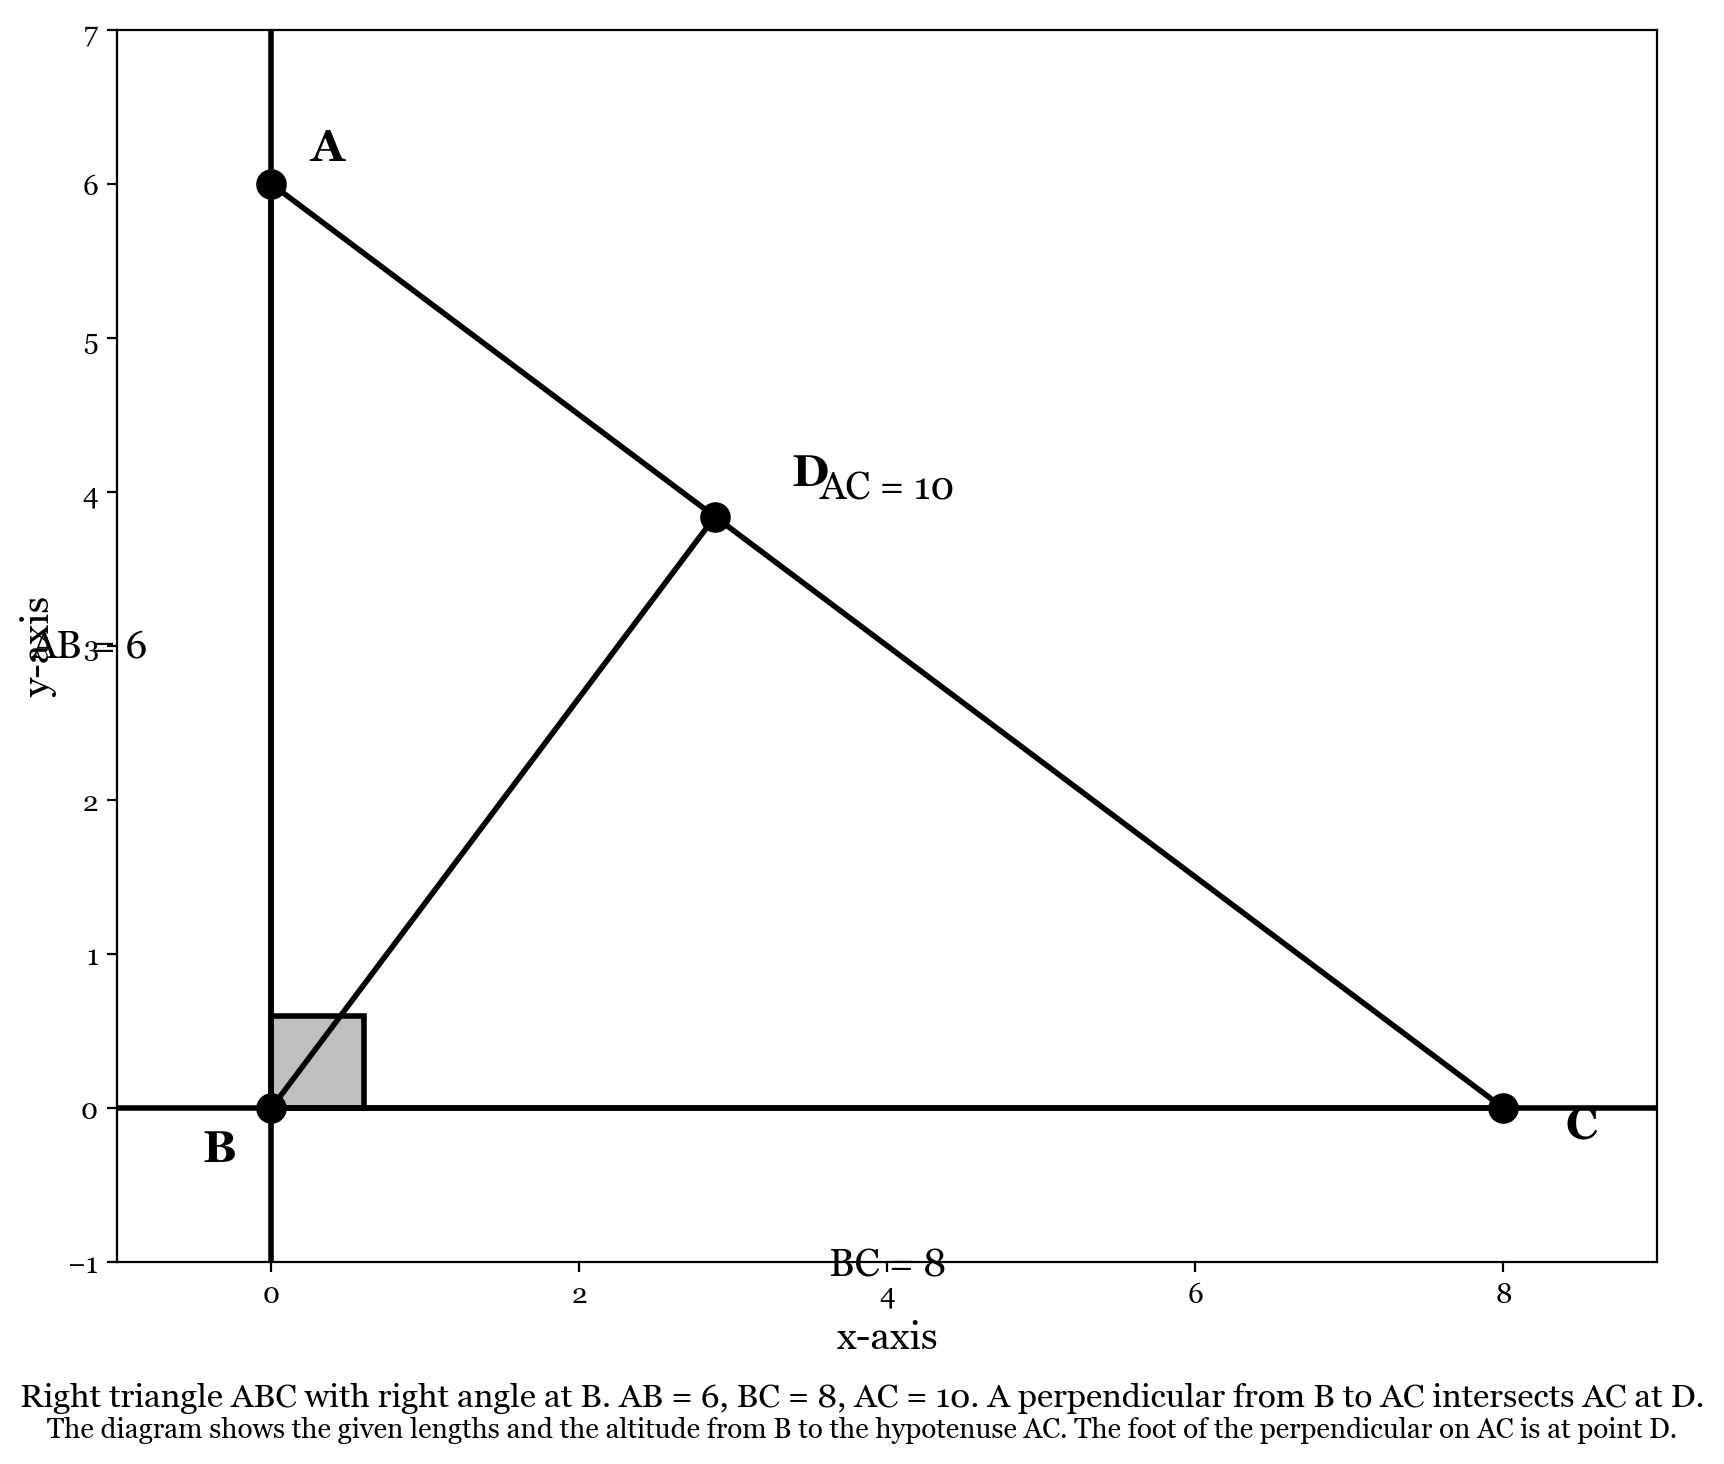

In [40]:
# Cell: Export SAT Question to HTML (always include passage/diagram)
import os
from IPython.display import HTML

# Determine question type and build HTML accordingly
html_parts = [
    '<html><head><meta charset="UTF-8"><title>Latest SAT Question</title>',
    '<style>body { font-family: Arial, sans-serif; background: #f9f9f9; margin: 0; padding: 0; }',
    '.container { max-width: 800px; margin: 40px auto; background: #fff; border-radius: 10px; box-shadow: 0 2px 8px #0001; padding: 32px; }',
    'h2 { color: #2c3e50; text-align: center; }',
    '.diagram { text-align: center; margin: 24px 0; }',
    '.choices { margin: 24px 0; }',
    '.choices li { background: #f0f0f0; margin: 8px 0; padding: 12px; border-radius: 4px; font-size: 16px; }',
    '.question { font-size: 18px; margin-bottom: 16px; }',
    '.passage { font-size: 17px; margin-bottom: 18px; background: #f6f6ff; border-left: 4px solid #667eea; padding: 16px; border-radius: 6px; }',
    '</style></head><body><div class="container">'
]

# Reading question (with passage)
if 'passage' in question_data:
    html_parts.append('<h2>SAT Reading Question</h2>')
    html_parts.append(f'<div class="passage"><strong>Passage:</strong><br>{question_data["passage"]}</div>')
    html_parts.append('<div class="question"><strong>Questions:</strong></div>')
    for i, q in enumerate(question_data.get('questions', [])):
        html_parts.append(f'<div class="question"><b>Q{i+1}:</b> {q}</div>')
        if 'answers' in question_data:
            html_parts.append(f'<div style="color:#555; margin-bottom:12px;"><b>Answer:</b> {question_data["answers"][i]}</div>')
else:
    # Math question (with diagram)
    html_parts.append('<h2>SAT Math Question</h2>')
    html_parts.append(f'<div class="question"><strong>Question:</strong> {question_data["question"]}</div>')
    # Always show diagram (fallback if missing)
    if img_base64:
        html_parts.append(f'<div class="diagram"><img src="data:image/png;base64,{img_base64}" style="max-width: 100%; border: 1px solid #ddd; border-radius: 5px;" /></div>')
    else:
        # Fallback: show a placeholder image with a message
        import base64
        from io import BytesIO
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(figsize=(6, 3))
        ax.axis('off')
        ax.text(0.5, 0.5, 'Diagram unavailable', ha='center', va='center', fontsize=18, color='gray', fontweight='bold')
        buffer = BytesIO()
        plt.savefig(buffer, format='png', bbox_inches='tight', dpi=120, facecolor='white')
        plt.close(fig)
        buffer.seek(0)
        fallback_img_base64 = base64.b64encode(buffer.getvalue()).decode()
        html_parts.append(f'<div class="diagram"><img src="data:image/png;base64,{fallback_img_base64}" style="max-width: 100%; border: 1px solid #ddd; border-radius: 5px;" /><div style="color:#888; font-size:15px; margin-top:8px;">Diagram unavailable</div></div>')
    html_parts.append('<div class="choices"><strong>Answer Choices:</strong><ul>')
    for choice in question_data.get('choices', []):
        html_parts.append(f'<li>{choice}</li>')
    html_parts.append('</ul></div>')

html_parts.append('</div></body></html>')

html_output = ''.join(html_parts)

# Save to file
output_dir = os.path.join(os.getcwd(), 'question-generation', 'output')
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'latest-sat-question.html')
with open(output_path, 'w', encoding='utf-8') as f:
    f.write(html_output)

print(f"✓ HTML export complete: {output_path}")
display(HTML(html_output))

In [5]:
import os
import random
import json
batch_dir = 'd:/DuckSAT/generated_batches/sample_batch'
num_questions = 10
os.makedirs(batch_dir, exist_ok=True)
def generate_question_and_diagram(idx):
    categories = ['Algebra', 'Geometry', 'Statistics', 'Reading', 'Writing']
    options = ["A", "B", "C", "D"]
    correct = random.randint(0, 3)
    question = f"Sample Question {idx+1}: What is {random.randint(1, 20)} + {random.randint(1, 20)}?"
    explanation = f"The answer is the sum of the two numbers."
    category = random.choice(categories)
    qdata = {
        "question": question,
        "options": options,
        "correctAnswer": correct,
        "explanation": explanation,
        "category": category,
        "moduleType": "math" if category in ['Algebra', 'Geometry', 'Statistics'] else "reading-writing"
    }
    with open(os.path.join(batch_dir, f"question_{idx+1}.json"), "w") as f:
        json.dump(qdata, f, indent=2)
    print(f"Saved: {os.path.join(batch_dir, f'question_{idx+1}.json')}")
for i in range(num_questions):
    generate_question_and_diagram(i)

Saved: d:/DuckSAT/generated_batches/sample_batch\question_1.json
Saved: d:/DuckSAT/generated_batches/sample_batch\question_2.json
Saved: d:/DuckSAT/generated_batches/sample_batch\question_3.json
Saved: d:/DuckSAT/generated_batches/sample_batch\question_4.json
Saved: d:/DuckSAT/generated_batches/sample_batch\question_5.json
Saved: d:/DuckSAT/generated_batches/sample_batch\question_6.json
Saved: d:/DuckSAT/generated_batches/sample_batch\question_7.json
Saved: d:/DuckSAT/generated_batches/sample_batch\question_8.json
Saved: d:/DuckSAT/generated_batches/sample_batch\question_9.json
Saved: d:/DuckSAT/generated_batches/sample_batch\question_10.json


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
C:\Users\lionv\AppData\Local\Temp\ipykernel_33468\2945689572.py:65: UserWarning: Glyph 10178 (\N{PERPENDICULAR}) missing from font(s) Georgia.
  plt.savefig(buffer, format='png', bbox_inches='tight', dpi=150, facecolor='white')
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
<string>:81: UserWarning: Glyph 8736 (\N{ANGLE}) missing from font(s) Georgia.
<string>:83: UserWarning: Glyph 8736 (\N{ANGLE}) missing from font(s) Georgia.
<string>:96: UserWarning: Glyph 10178 (\N{PERPENDICULAR}) missing from font(s) Georgia.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
<string>:85: UserWarning: Glyph 10178 (\N{PERPENDICULAR}) missing from font(s) Georgia.
<string>:85: UserWarning: Glyph 10178 (\N{PERPENDICULAR}) missing from font(s) Georgia.
<string>:89: UserWarni

triangle_diagram.png


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
<string>:97: UserWarning: Glyph 8736 (\N{ANGLE}) missing from font(s) Georgia.
<string>:85: UserWarning: Glyph 10178 (\N{PERPENDICULAR}) missing from font(s) Georgia.


APITimeoutError: Request timed out.

d:\DuckSAT\.venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 10178 (\N{PERPENDICULAR}) missing from font(s) Georgia.
  func(*args, **kwargs)
d:\DuckSAT\.venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 8736 (\N{ANGLE}) missing from font(s) Georgia.
  func(*args, **kwargs)


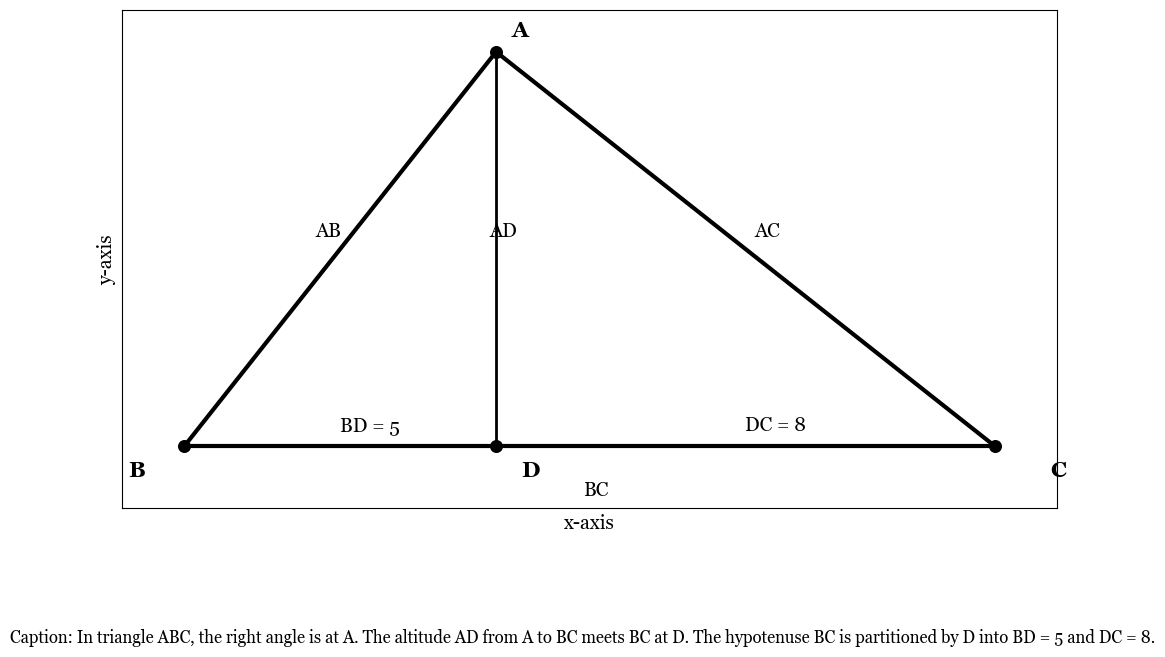

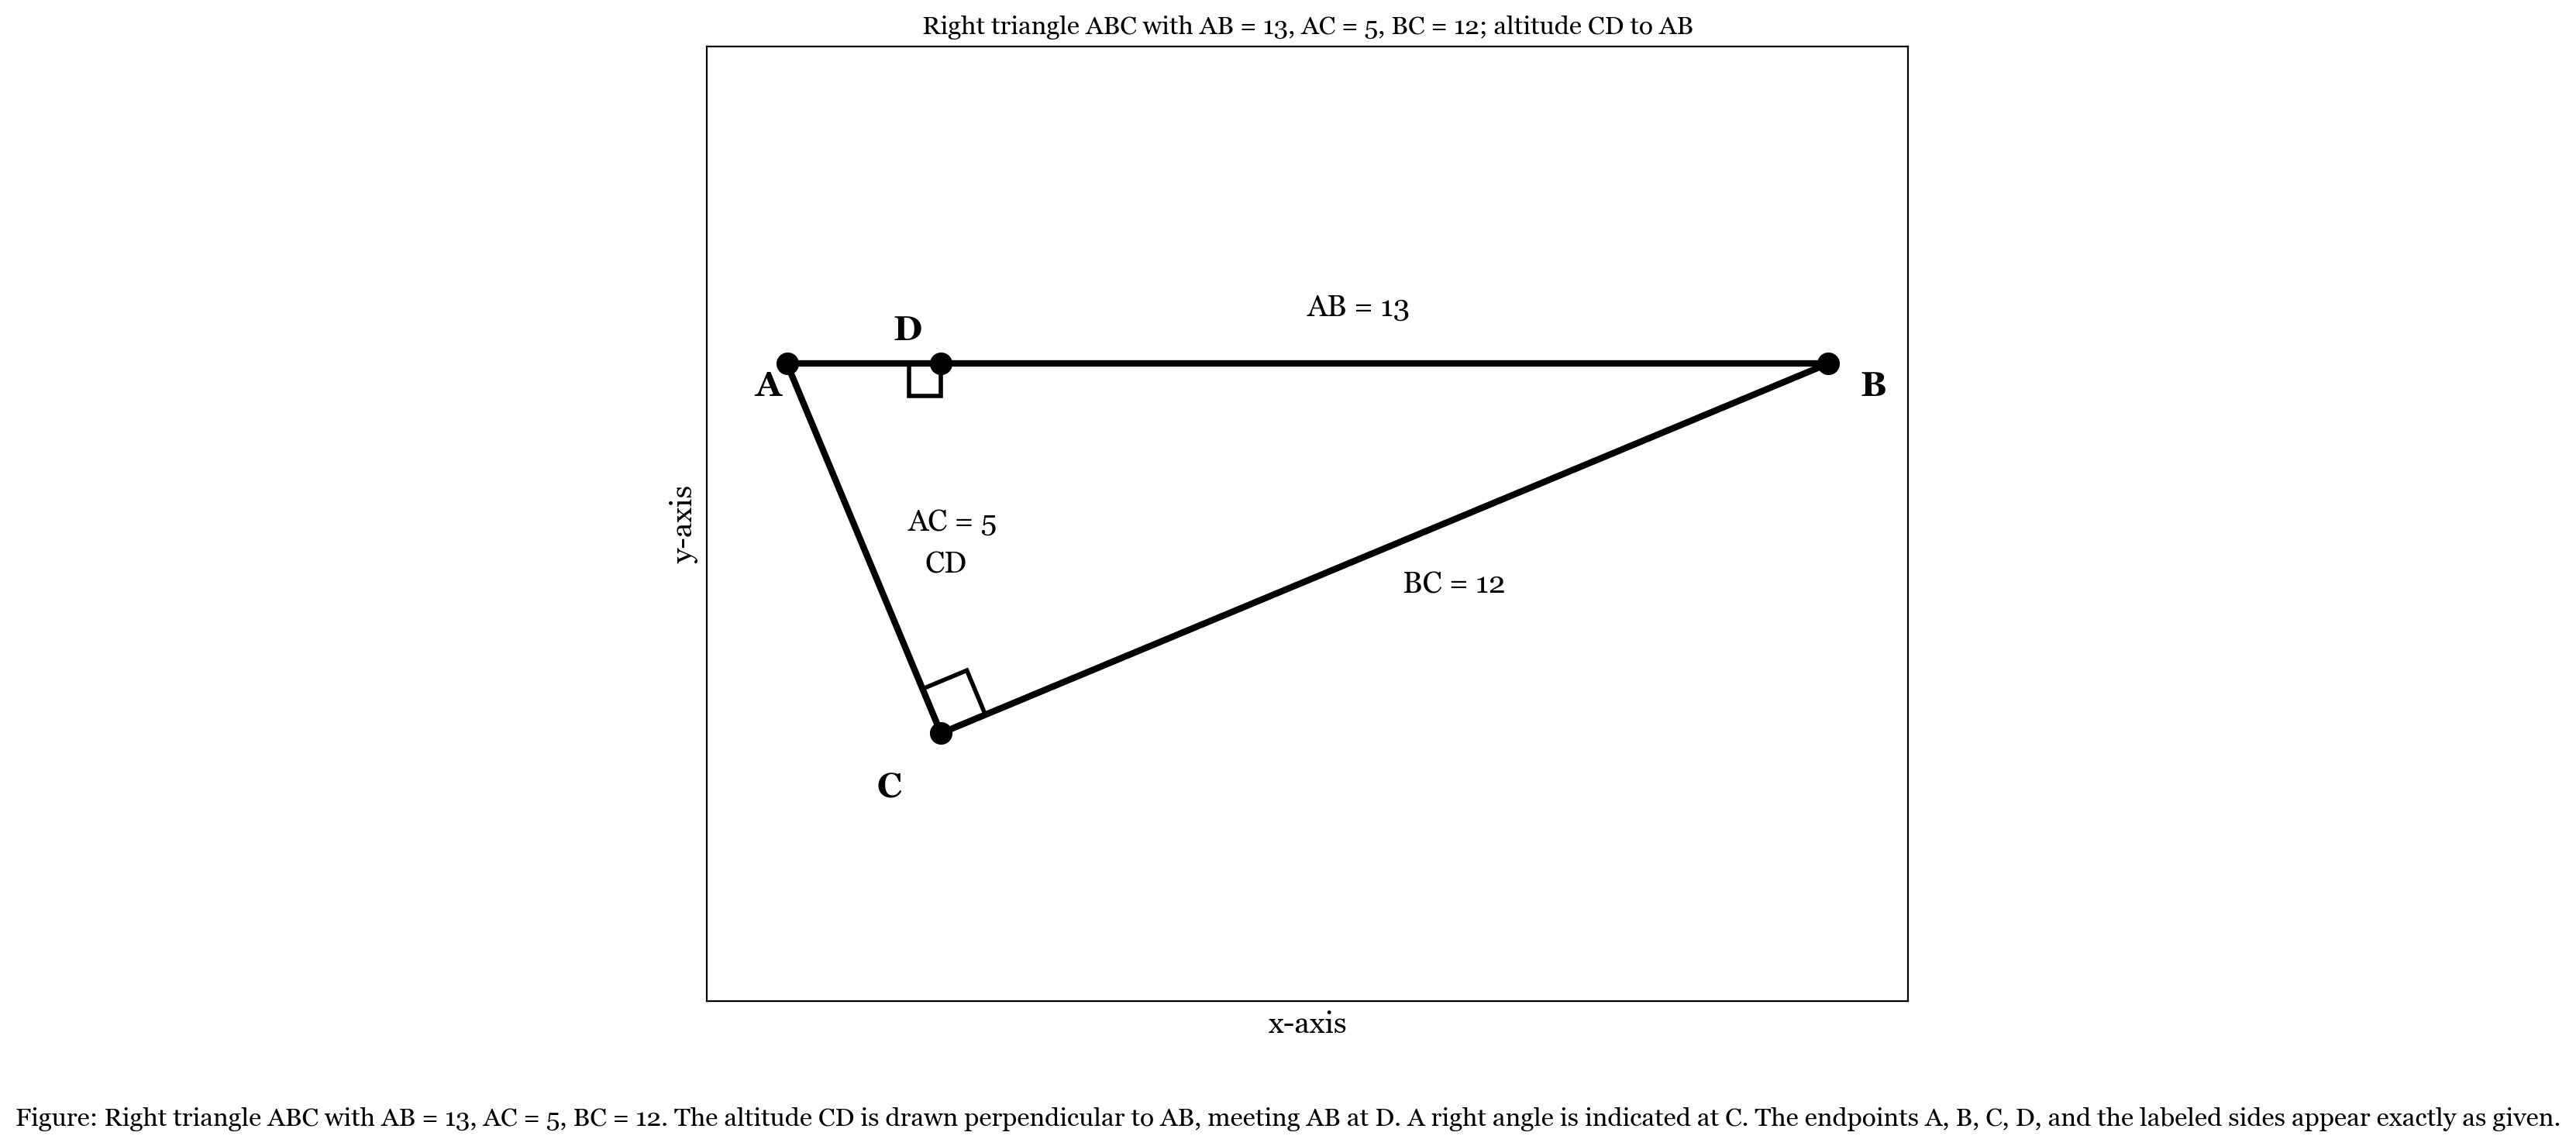

d:\DuckSAT\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10178 (\N{PERPENDICULAR}) missing from font(s) Georgia.
  fig.canvas.print_figure(bytes_io, **kw)


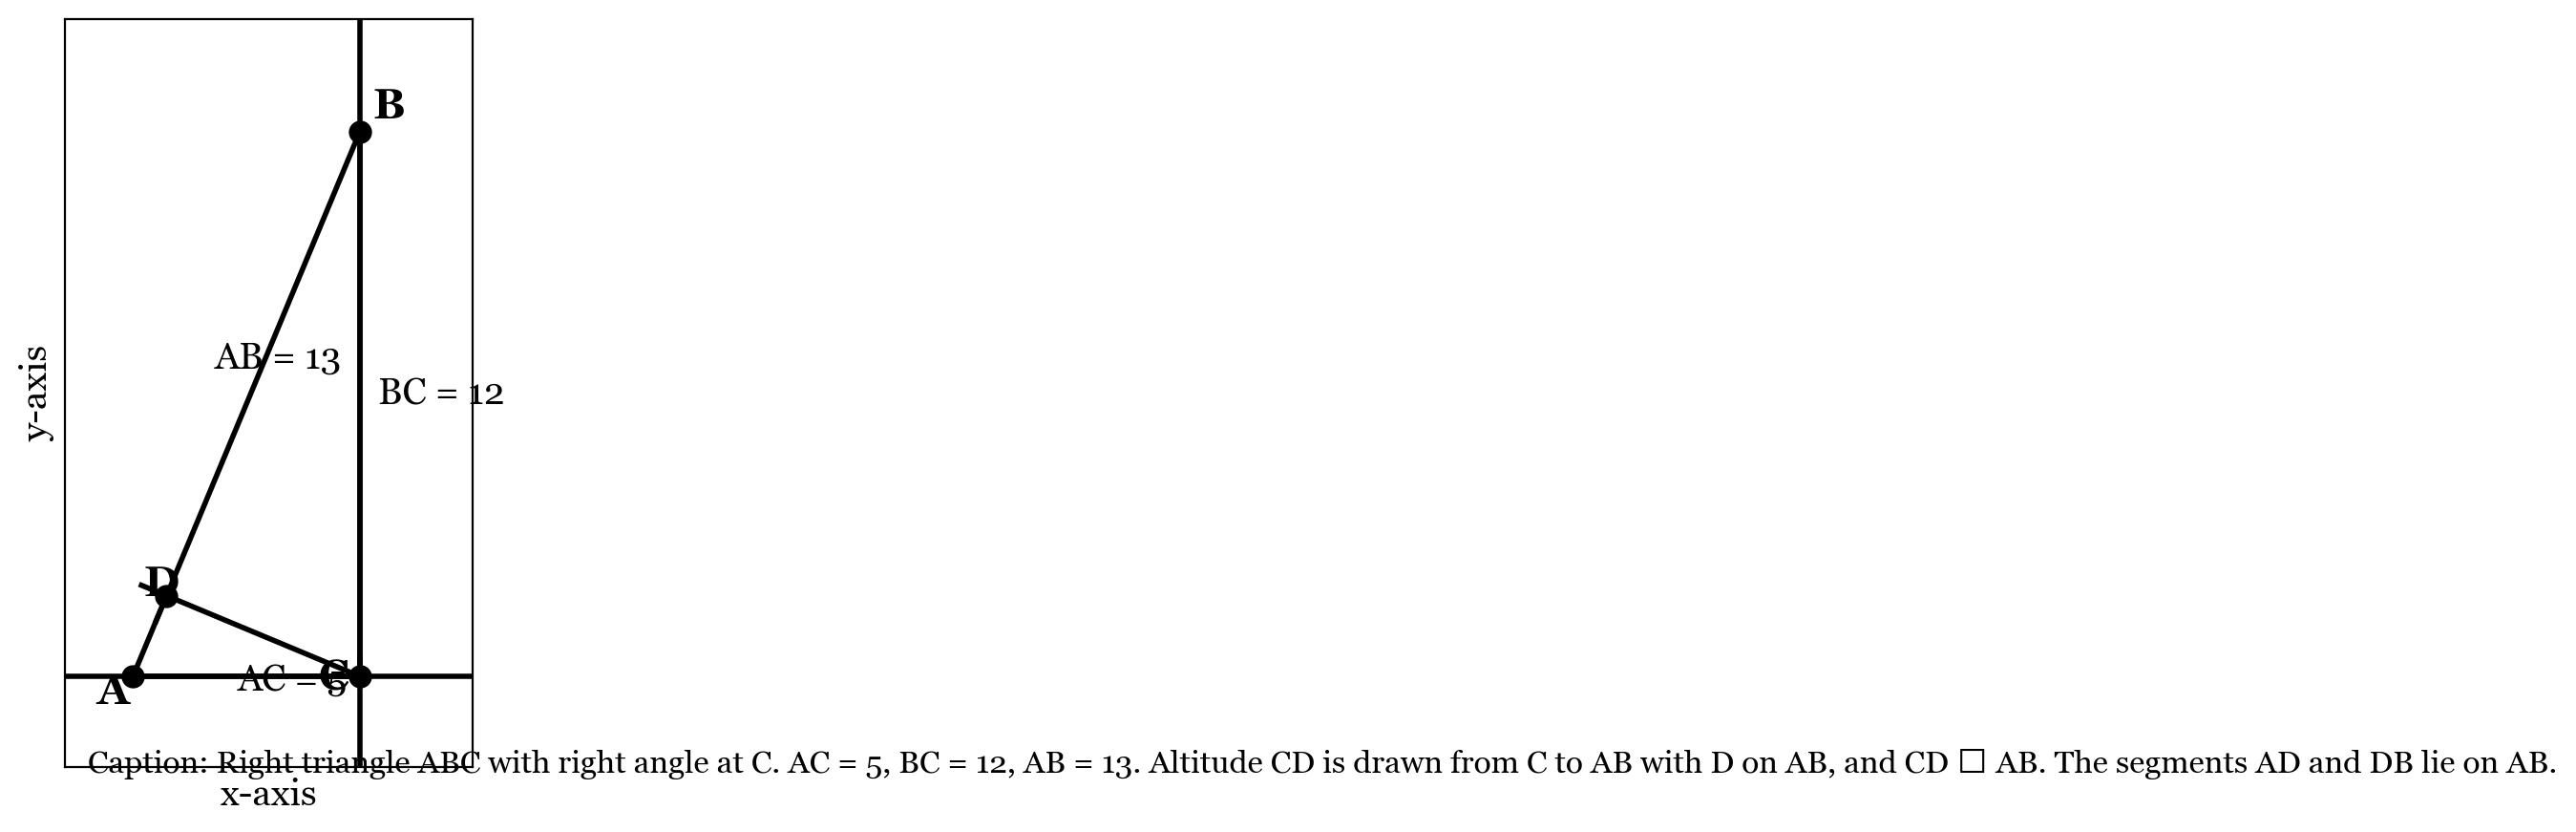

<Figure size 640x480 with 0 Axes>

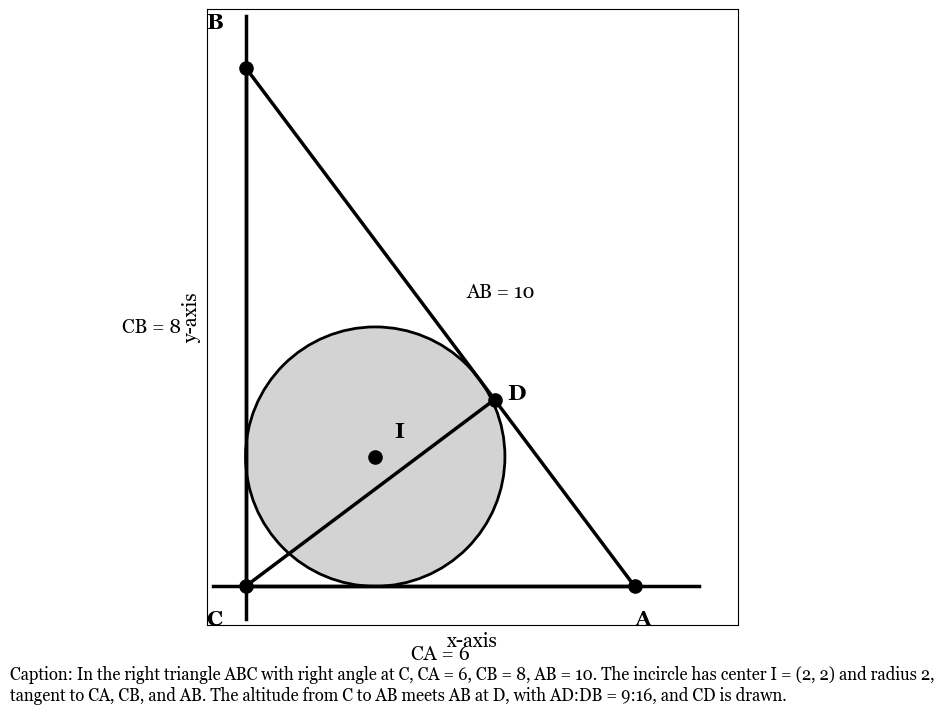

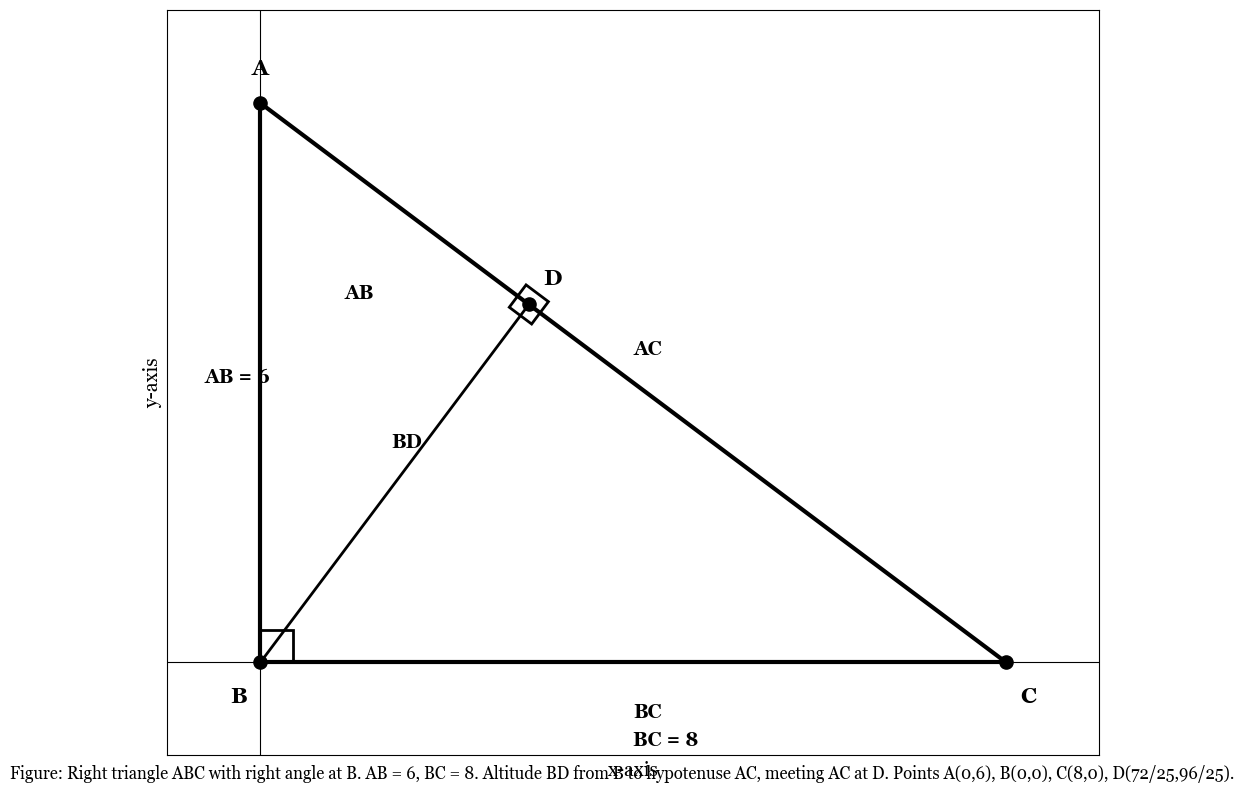

d:\DuckSAT\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8736 (\N{ANGLE}) missing from font(s) Georgia.
  fig.canvas.print_figure(bytes_io, **kw)


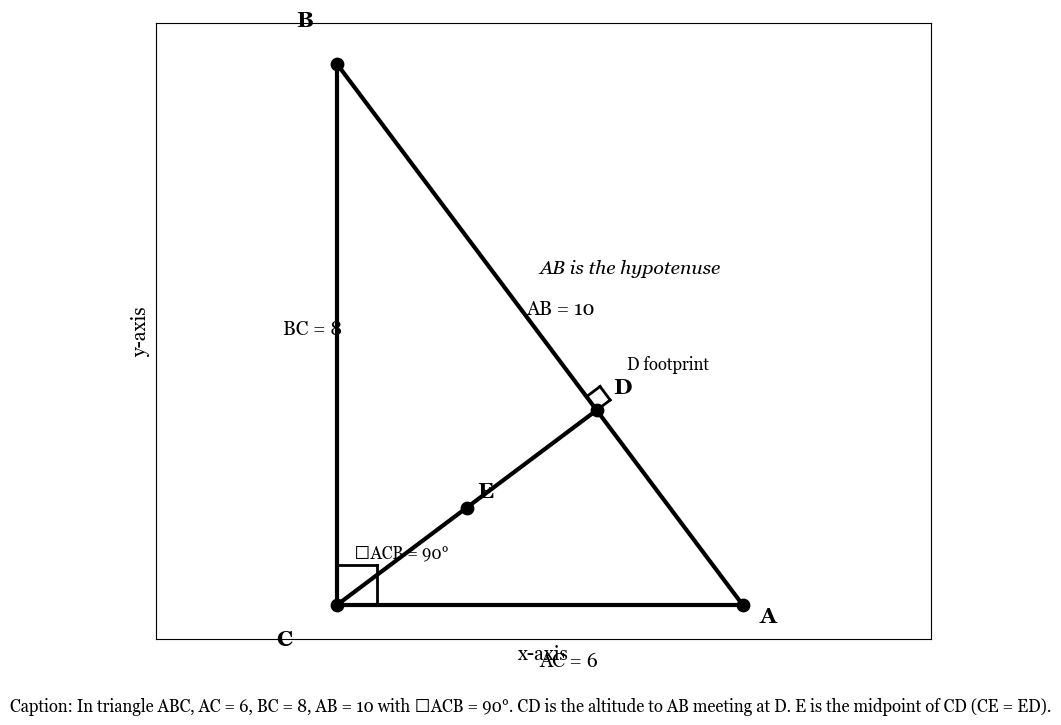

In [3]:
# Cell: Refactored batch generator using functions
import os, time, json, base64
from io import BytesIO
import matplotlib.pyplot as plt
from IPython.display import display, HTML

def generate_sat_math_question():
    response = client.chat.completions.create(
        model=deployment_name,
        messages=[
            {"role": "system", "content": "You are an expert SAT math question writer. Create challenging SAT math questions that require a visual diagram. The diagram must be contextually relevant and include all lines, labels, axes, graphs, and geometric figures described in the question. Do NOT create generic coordinate planes with only points unless the question specifically requires it."},
            {"role": "user", "content": """Create a single SAT math question that requires a diagram. The diagram can be a bar chart, geometry figure, graph, coordinate plane with axes, or algebraic figure, but it must match the context of the question. Return ONLY a JSON object with this exact structure:\n{\n    \"question\": \"the question text\",\n    \"choices\": [\"A) choice 1\", \"B) choice 2\", \"C) choice 3\", \"D) choice 4\"],\n    \"diagram_description\": \"detailed description of what to show in the diagram\"\n}\n\nIMPORTANT: In the diagram_description, specify ONLY what should be drawn (the given information), NOT what the question is asking for.\n\nThe diagram should show all GIVEN information clearly (shapes, labels, known measurements, angles, lines, axes, graphs) but should NOT reveal the answer or show the unknown quantity being asked for.\n\nMake the question challenging but solvable from the diagram. The diagram must include all lines, labels, axes, and context described in the question. Do NOT create a generic coordinate plane with only points unless the question specifically requires it."""}
        ],
        response_format={"type": "json_object"}
    )
    question_data = json.loads(response.choices[0].message.content)
    return question_data

def generate_sat_reading_question():
    response = client.chat.completions.create(
        model=deployment_name,
        messages=[
            {"role": "system", "content": "You are an expert SAT reading comprehension question writer. Create challenging, creative, and varied reading passages (narrative, informational, argumentative) and generate 2-4 comprehension questions for each passage."},
            {"role": "user", "content": """Create a single SAT reading passage (narrative, informational, or argumentative) and 2-4 comprehension questions. Return ONLY a JSON object with this exact structure:\n{\n    \"passage\": \"the passage text\",\n    \"questions\": [\"question 1\", \"question 2\", ...],\n    \"answers\": [\"answer 1\", \"answer 2\", ...],\n    \"question_types\": [\"main idea\", \"detail\", ...]\n}\nMake the passage interesting and the questions varied (main idea, detail, inference, vocabulary, etc.)."""}
        ],
        response_format={"type": "json_object"}
    )
    reading_data = json.loads(response.choices[0].message.content)
    return reading_data

def generate_diagram_img_base64(diagram_description, question_text):
    diagram_response = client.chat.completions.create(
        model=deployment_name,
        messages=[
            {"role": "system", "content": "You are an expert in creating matplotlib code for mathematical diagrams. You must create diagrams that EXACTLY match the problem description with NO errors or inconsistencies. The diagram must include all lines, labels, axes, graphs, and context described in the question. Do NOT create a generic coordinate plane with only points unless the question specifically requires it."},
            {"role": "user", "content": f'''Create Python matplotlib code to draw this diagram: {diagram_description}\n\nCRITICAL REQUIREMENTS - READ CAREFULLY:\n\nGEOMETRIC ACCURACY (MOST IMPORTANT):\n1. If drawing a triangle, the three points MUST NOT be collinear (on the same line)\n2. If the question mentions coordinates, use EXACT coordinate values from the problem\n3. Calculate point positions mathematically to ensure geometric relationships are correct\n4. For ratios like AD:DB = 1:3, calculate exact positions: if A=(0,0) and B=(8,0), then D=(2,0)\n5. Verify all points are positioned correctly before drawing\n\nDIAGRAM-QUESTION MATCH:\n6. The diagram MUST exactly match the problem statement in {question_text}\n7. Every point, line, label, axis, and graph mentioned in the question MUST appear correctly in the diagram\n8. If the question says 'tangent line ℓ', draw and label it as 'ℓ' or 'line ℓ'\n9. If the question says 'line ℓ touches at point T', then point T MUST be on the circle where the tangent touches\n10. Point labels must be EXACTLY where the question describes them\n11. DO NOT invent point names or positions not mentioned in the question\n\nCLARITY:\n12. If a line is mentioned, draw it and label it clearly\n13. ONLY show GIVEN information - DO NOT show the answer or unknown measurements\n14. DO NOT overlap labels or points\n15. Label axes if mentioned (e.g., x-axis, y-axis)\n16. DRAW AXES with thick lines if the question mentions coordinate axes\n\nReturn ONLY a JSON object with this structure:\n{{\n    'code': 'complete matplotlib code that creates the figure and saves it'\n}}\n\nDiagram quality requirements:\n- Import ONLY: matplotlib.pyplot as plt, numpy as np, matplotlib.patches (Circle, Polygon, etc.), and BytesIO from io\n- DO NOT import shapely, geopandas, or other non-standard geometry libraries\n- Create figure with figsize=(10, 8)\n- Use thick lines (linewidth=2-3) for main shapes\n- Use only black and white colors for shapes and lines. You can use greyscale shades for fill if needed.\n- Label ALL points with fontsize=16, fontweight='bold'\n- Label all lines and axes mentioned in the problem (e.g., 'line ℓ', 'tangent line', x-axis, y-axis, etc.) with fontsize=14\n- Show GIVEN measurements clearly (e.g., 'r = 6', 'AB = 8') with fontsize=14\n- Position labels carefully outside shapes to avoid overlap\n- Use markers (markersize=8-10) for all important points\n- Use ax.axis('equal') for accurate geometry\n- Axes must have markings and numbers if relevant\n- Axes must have labels\n- There must be a vertical line and horizontal line passing through the origin if axes are required\n- Diagrams must have captions and description\n- Use Georgia font\n- Use caption for graphs and also for barcharts\n- Must use axes labels, axes markings even for bar charts \n- Captions, diagrams, and labels must not overlap, or be too close to each other\n- Add spaces between labels and shapes so that they do not overlap and are clearly visible\n- Labels must not overlap with points or lines or with another label\n- Remove axis ticks with ax.set_xticks([]) and ax.set_yticks([])\n- Set appropriate limits to show the entire figure clearly\n- Use dpi=200 for crisp rendering\n- Keep code simple - use basic matplotlib plotting functions only\n\nBEFORE generating code, mentally verify:\n- Does my diagram match every detail in the question?\n- Are all points, lines, axes, and labels positioned where described?\n- Am I showing only GIVEN information, not the answer?\n\nReturn ONLY the JSON with the complete code.'''}
        ],
        response_format={"type": "json_object"}
    )
    diagram_code_data = json.loads(diagram_response.choices[0].message.content)
    img_base64 = None
    try:
        exec_globals = {'BytesIO': BytesIO}
        exec(diagram_code_data['code'], exec_globals)
        if 'buffer' in exec_globals:
            buffer = exec_globals['buffer']
            buffer.seek(0)
            img_base64 = base64.b64encode(buffer.getvalue()).decode()
        else:
            for key, value in exec_globals.items():
                if isinstance(value, BytesIO):
                    buffer = value
                    buffer.seek(0)
                    img_base64 = base64.b64encode(buffer.getvalue()).decode()
                    break
            else:
                raise Exception("No buffer variable found in generated code")
    except Exception:
        fig, ax = plt.subplots(figsize=(10, 8))
        ax.text(0.5, 0.5, "Diagram could not be generated.\n\nDescription:\n" + diagram_description, ha='center', va='center', wrap=True, fontsize=12, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.axis('off')
        buffer = BytesIO()
        plt.savefig(buffer, format='png', bbox_inches='tight', dpi=150, facecolor='white')
        plt.close()
        buffer.seek(0)
        img_base64 = base64.b64encode(buffer.getvalue()).decode()
    return img_base64

def export_html_math(question_data, img_base64, out_path):
    html_parts = [
        '<html><head><meta charset="UTF-8"><title>SAT Math Question</title>',
        '<style>body { font-family: Arial, sans-serif; background: #f9f9f9; margin: 0; padding: 0; }',
        '.container { max-width: 800px; margin: 40px auto; background: #fff; border-radius: 10px; box-shadow: 0 2px 8px #0001; padding: 32px; }',
        'h2 { color: #2c3e50; text-align: center; }',
        '.diagram { text-align: center; margin: 24px 0; }',
        '.choices { margin: 24px 0; }',
        '.choices li { background: #f0f0f0; margin: 8px 0; padding: 12px; border-radius: 4px; font-size: 16px; }',
        '.question { font-size: 18px; margin-bottom: 16px; }',
        '</style></head><body><div class="container">'
    ]
    html_parts.append('<h2>SAT Math Question</h2>')
    html_parts.append(f'<div class="question"><strong>Question:</strong> {question_data["question"]}</div>')
    if img_base64:
        html_parts.append(f'<div class="diagram"><img src="data:image/png;base64,{img_base64}" style="max-width: 100%; border: 1px solid #ddd; border-radius: 5px;" /></div>')
    else:
        fig, ax = plt.subplots(figsize=(6, 3))
        ax.axis('off')
        ax.text(0.5, 0.5, 'Diagram unavailable', ha='center', va='center', fontsize=18, color='gray', fontweight='bold')
        buffer = BytesIO()
        plt.savefig(buffer, format='png', bbox_inches='tight', dpi=120, facecolor='white')
        plt.close(fig)
        buffer.seek(0)
        fallback_img_base64 = base64.b64encode(buffer.getvalue()).decode()
        html_parts.append(f'<div class="diagram"><img src="data:image/png;base64,{fallback_img_base64}" style="max-width: 100%; border: 1px solid #ddd; border-radius: 5px;" /><div style="color:#888; font-size:15px; margin-top:8px;">Diagram unavailable</div></div>')
    html_parts.append('<div class="choices"><strong>Answer Choices:</strong><ul>')
    for choice in question_data.get('choices', []):
        html_parts.append(f'<li>{choice}</li>')
    html_parts.append('</ul></div>')
    html_parts.append('</div></body></html>')
    html_output = ''.join(html_parts)
    with open(out_path, 'w', encoding='utf-8') as f:
        f.write(html_output)
    return html_output

def export_html_reading(reading_data, out_path):
    html_parts = [
        '<html><head><meta charset="UTF-8"><title>SAT Reading Question</title>',
        '<style>body { font-family: Arial, sans-serif; background: #f9f9f9; margin: 0; padding: 0; }',
        '.container { max-width: 800px; margin: 40px auto; background: #fff; border-radius: 10px; box-shadow: 0 2px 8px #0001; padding: 32px; }',
        'h2 { color: #2c3e50; text-align: center; }',
        '.passage { font-size: 17px; margin-bottom: 18px; background: #f6f6ff; border-left: 4px solid #667eea; padding: 16px; border-radius: 6px; }',
        '.question { font-size: 18px; margin-bottom: 16px; }',
        '.questions-list { margin: 24px 0; }',
        '.questions-list li { background: #f0f0f0; margin: 8px 0; padding: 12px; border-radius: 4px; font-size: 16px; }',
        '</style></head><body><div class="container">'
    ]
    html_parts.append('<h2>SAT Reading Question</h2>')
    html_parts.append(f'<div class="passage"><strong>Passage:</strong><br>{reading_data["passage"]}</div>')
    html_parts.append('<div class="questions-list"><strong>Questions:</strong><ul>')
    for i, q in enumerate(reading_data.get('questions', [])):
        html_parts.append(f'<li><b>Q{i+1}:</b> {q}<br><span style="color:#555;"><b>Answer:</b> {reading_data["answers"][i]}</span></li>')
    html_parts.append('</ul></div>')
    html_parts.append('</div></body></html>')
    html_output = ''.join(html_parts)
    with open(out_path, 'w', encoding='utf-8') as f:
        f.write(html_output)
    return html_output

# Generate preview files for 100 math and 100 reading questions
preview_dir = os.path.join(os.getcwd(), 'question-generation', 'output', 'preview')
os.makedirs(preview_dir, exist_ok=True)
math_htmls = []
reading_htmls = []
for i in range(100):
    qdata = generate_sat_math_question()
    img_b64 = generate_diagram_img_base64(qdata['diagram_description'], qdata['question'])
    out_path = os.path.join(preview_dir, f'math-question-{i+1}.html')
    html = export_html_math(qdata, img_b64, out_path)
    math_htmls.append(html)
    time.sleep(1)
for i in range(100):
    rdata = generate_sat_reading_question()
    out_path = os.path.join(preview_dir, f'reading-question-{i+1}.html')
    html = export_html_reading(rdata, out_path)
    reading_htmls.append(html)
    time.sleep(1)
print(f"100 math and 100 reading preview HTML files generated in {preview_dir}")
display(HTML(f'<b>100 math and 100 reading preview HTML files generated in <code>{preview_dir}</code></b>'))


In [ ]:
# Combine all generated questions into a single HTML file (like 50-questions-display.html)
combined_html_path = os.path.join(os.getcwd(), 'question-generation', 'output', 'sat-20-questions-preview.html')

def extract_body_content(html):
    start = html.find('<body>')
    end = html.find('</body>')
    if start != -1 and end != -1:
        return html[start+6:end]
    return html

with open(combined_html_path, 'w', encoding='utf-8') as f:
    f.write('<!DOCTYPE html>\n<html lang="en">\n<head>\n  <meta charset="UTF-8">\n  <meta name="viewport" content="width=device-width, initial-scale=1.0">\n  <title>20 SAT Practice Questions</title>\n  <link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/katex@0.16.9/dist/katex.min.css">\n  <script defer src="https://cdn.jsdelivr.net/npm/katex@0.16.9/dist/katex.min.js"></script>\n  <script defer src="https://cdn.jsdelivr.net/npm/katex@0.16.9/dist/contrib/auto-render.min.js"\n          onload="renderMathInElement(document.body, {delimiters: [{left: \'$\', right: \'$\', display: false}, {left: \'$$\', right: \'$$\', display: true}], throwOnError: false});"></script>\n  <style>body { font-family: Arial, sans-serif; background: #f5f5f5; padding: 20px; } .container { max-width: 1200px; margin: 0 auto; background: white; padding: 40px; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.1); } h1 { text-align: center; margin-bottom: 30px; } .section-header { font-size: 1.5em; margin-top: 40px; margin-bottom: 20px; color: #007bff; border-bottom: 2px solid #007bff; padding-bottom: 8px; } .question-card { background: #f9f9f9; border-radius: 8px; box-shadow: 0 1px 3px #0001; margin-bottom: 24px; padding: 24px; } .question-text { font-size: 18px; margin-bottom: 16px; } .diagram { text-align: center; margin: 16px 0; } .diagram img { max-width: 100%; border: 1px solid #ddd; border-radius: 5px; } .choices { margin: 16px 0; } .choices li { background: #f0f0f0; margin: 8px 0; padding: 12px; border-radius: 4px; font-size: 16px; } .passage { font-size: 17px; margin-bottom: 18px; background: #f6f6ff; border-left: 4px solid #667eea; padding: 16px; border-radius: 6px; } .questions-list li { background: #f0f0f0; margin: 8px 0; padding: 12px; border-radius: 4px; font-size: 16px; } </style>\n</head>\n<body>\n  <div class="container">\n    <h1>20 SAT Practice Questions</h1>\n    <div class="section-header">Math Questions</div>\n')
    for html in math_htmls:
        f.write(extract_body_content(html))
    f.write('<div class="section-header">Reading Questions</div>\n')
    for html in reading_htmls:
        f.write(extract_body_content(html))
    f.write('  </div>\n</body>\n</html>')
print(f"Combined HTML file created at {combined_html_path}")
display(HTML(f'<b>Combined HTML file created at <code>{combined_html_path}</code></b>'))
